# Task 1

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

In [6]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

df = adult.frame.copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [7]:
df["target"] = (
    df["class"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
    .map({
        "<=50K": 0,
        ">50K": 1
    })
)

df.drop(columns=["class"], inplace=True)

print(df["target"].value_counts())

target
0    37155
1    11687
Name: count, dtype: int64


In [11]:
X = df.drop(columns=["target"])
y = df["target"]

X_train_dev, X_test, y_train_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [12]:
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train_dev,
    y_train_dev,
    test_size=0.10,
    stratify=y_train_dev,
    random_state=RANDOM_STATE
)

In [13]:
print("Training:", X_train.shape)
print("Development:", X_dev.shape)
print("Hold-out Test:", X_test.shape)

Training: (35165, 14)
Development: (3908, 14)
Hold-out Test: (9769, 14)


In [14]:
from sklearn.base import BaseEstimator, TransformerMixin

In [15]:
class AdultFeatureEngineer(
    BaseEstimator,
    TransformerMixin
):

    def fit(
        self,
        X,
        y=None
    ):
        return self

    def transform(
        self,
        X
    ):

        X = X.copy()

        # 1. Age bucket
        X["age_bucket"] = pd.cut(
            X["age"],
            bins=[
                0,
                25,
                35,
                50,
                65,
                np.inf
            ],
            labels=[
                "Young",
                "Early_Career",
                "Mid_Career",
                "Senior",
                "Older"
            ]
        ).astype(object)

        # 2. Hours-per-week bucket
        X["hours_bucket"] = pd.cut(
            X["hours-per-week"],
            bins=[
                0,
                20,
                40,
                60,
                np.inf
            ],
            labels=[
                "Part_Time",
                "Standard",
                "Long_Hours",
                "Very_Long_Hours"
            ]
        ).astype(object)

        # 3. Capital gain flag
        X["capital_gain_flag"] = (
            X["capital-gain"] > 0
        ).astype(int)

        # 4. Log capital gain
        X["log_capital_gain"] = np.log1p(
            X["capital-gain"]
        )

        # 5. Higher education
        X["higher_education"] = (
            X["education-num"] >= 13
        ).astype(int)

        # 6. Education-hours interaction
        X["education_hours_interaction"] = (
            X["education-num"]
            *
            X["hours-per-week"]
        )

        return X

In [18]:
feature_engineer = AdultFeatureEngineer()

X_engineered = feature_engineer.fit_transform(
    X_train_dev
)

print(
    "Original shape:",
    X_train_dev.shape
)

print(
    "Engineered shape:",
    X_engineered.shape
)

new_features = [
    "age_bucket",
    "hours_bucket",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction"
]

X_engineered[
    new_features
].head()

Original shape: (39073, 14)
Engineered shape: (39073, 20)


,age_bucket,hours_bucket,capital_gain_flag,log_capital_gain,higher_education,education_hours_interaction
34342,Older,Part_Time,0,0.0,0,153
18559,Young,Part_Time,0,0.0,0,60
12477,Early_Career,Standard,0,0.0,0,360
560,Mid_Career,Standard,0,0.0,0,360
3427,Early_Career,Standard,0,0.0,1,520


### Feature Dictionary

In [19]:
feature_dictionary = pd.DataFrame({
    "Feature": [
        "age_bucket",
        "hours_bucket",
        "capital_gain_flag",
        "log_capital_gain",
        "higher_education",
        "education_hours_interaction"
    ],

    "Type": [
        "Categorical",
        "Categorical",
        "Binary",
        "Numeric",
        "Binary",
        "Numeric"
    ],

    "Creation Rule": [
        "Age grouped into career-stage ranges",
        "Hours-per-week grouped into workload ranges",
        "1 if capital-gain > 0, else 0",
        "log(1 + capital-gain)",
        "1 if education-num >= 13, else 0",
        "education-num × hours-per-week"
    ],

    "Justification": [
        "Captures possible nonlinear relationship between age and income",
        "Captures nonlinear workload patterns",
        "Separates individuals with any investment gain from those with none",
        "Reduces skew caused by extreme capital-gain values",
        "Represents higher educational attainment explicitly",
        "Captures combined effect of education and working hours"
    ]
})

feature_dictionary

,Feature,Type,Creation Rule,Justification
0,age_bucket,Categorical,Age grouped into career-stage ranges,Captures possible nonlinear relationship betwe...
1,hours_bucket,Categorical,Hours-per-week grouped into workload ranges,Captures nonlinear workload patterns
2,capital_gain_flag,Binary,"1 if capital-gain > 0, else 0",Separates individuals with any investment gain...
3,log_capital_gain,Numeric,log(1 + capital-gain),Reduces skew caused by extreme capital-gain va...
4,higher_education,Binary,"1 if education-num >= 13, else 0",Represents higher educational attainment expli...
5,education_hours_interaction,Numeric,education-num × hours-per-week,Captures combined effect of education and work...


### Univariate Predictive Signal

In [20]:
X_engineered = feature_engineer.fit_transform(
    X_train_dev
)

In [21]:
engineered_features = [
    "age_bucket",
    "hours_bucket",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction"
]

X_mi = X_engineered[
    engineered_features
].copy()

In [22]:
for col in X_mi.select_dtypes(
    include=["object", "category"]
).columns:

    X_mi[col] = pd.factorize(
        X_mi[col]
    )[0]

In [23]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_mi,
    y_train_dev,
    random_state=RANDOM_STATE
)

mi_results = pd.DataFrame({
    "Feature": engineered_features,
    "Mutual_Information": mi_scores
}).sort_values(
    by="Mutual_Information",
    ascending=False
)

mi_results

,Feature,Mutual_Information
5,education_hours_interaction,0.078911
3,log_capital_gain,0.078653
0,age_bucket,0.058075
4,higher_education,0.049926
1,hours_bucket,0.034662
2,capital_gain_flag,0.029125


In [24]:
feature_dictionary = feature_dictionary.merge(
    mi_results,
    on="Feature",
    how="left"
)

feature_dictionary

,Feature,Type,Creation Rule,Justification,Mutual_Information
0,age_bucket,Categorical,Age grouped into career-stage ranges,Captures possible nonlinear relationship betwe...,0.058075
1,hours_bucket,Categorical,Hours-per-week grouped into workload ranges,Captures nonlinear workload patterns,0.034662
2,capital_gain_flag,Binary,"1 if capital-gain > 0, else 0",Separates individuals with any investment gain...,0.029125
3,log_capital_gain,Numeric,log(1 + capital-gain),Reduces skew caused by extreme capital-gain va...,0.078653
4,higher_education,Binary,"1 if education-num >= 13, else 0",Represents higher educational attainment expli...,0.049926
5,education_hours_interaction,Numeric,education-num × hours-per-week,Captures combined effect of education and work...,0.078911


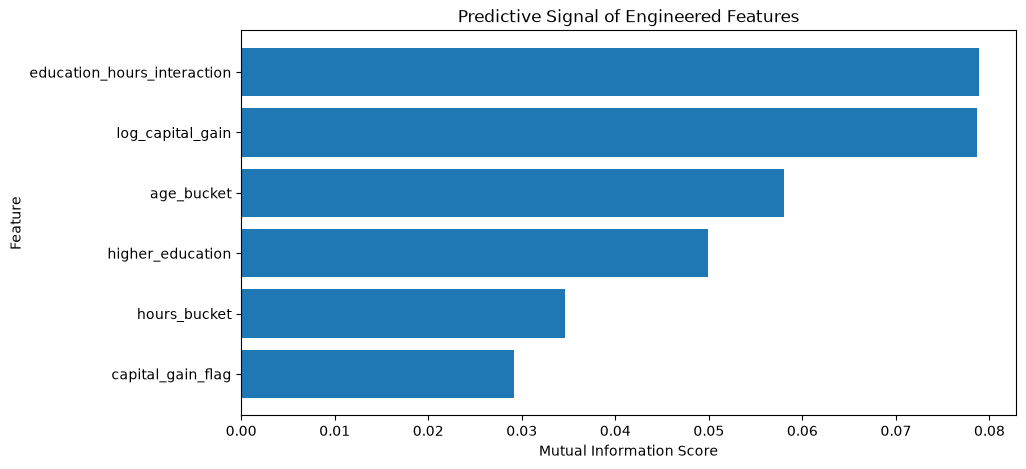

In [25]:
mi_plot = mi_results.sort_values(
    by="Mutual_Information"
)

plt.figure(figsize=(10, 5))

plt.barh(
    mi_plot["Feature"],
    mi_plot["Mutual_Information"]
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.title(
    "Predictive Signal of Engineered Features"
)

plt.show()

The mutual information analysis showed that all six engineered features contained some predictive signal for the income target. The strongest signals came from education_hours_interaction (0.078911) and log_capital_gain (0.078653), indicating that the combined relationship between education and working hours, as well as the transformed capital-gain variable, provide useful information for predicting whether an individual earns more than $50K.

The age_bucket feature (0.058075) and higher_education feature (0.049926) also showed meaningful predictive value, suggesting that career stage and educational attainment are associated with income. hours_bucket (0.034662) and capital_gain_flag (0.029125) had comparatively lower but still non-zero predictive signals. Overall, the results support retaining all engineered features for the initial cross-validation experiments because each captures a potentially useful aspect of the data.

# Task 2

In [26]:
X_sample_engineered = feature_engineer.fit_transform(
    X_train_dev.head()
)

numeric_features_engineered = (
    X_sample_engineered
    .select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    )
    .columns
    .tolist()
)

categorical_features_engineered = (
    X_sample_engineered
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

In [27]:
print(
    "Numeric Features:"
)

print(
    numeric_features_engineered
)

print(
    "\nCategorical Features:"
)

print(
    categorical_features_engineered
)

Numeric Features:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'capital_gain_flag', 'log_capital_gain', 'higher_education', 'education_hours_interaction']

Categorical Features:
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'age_bucket', 'hours_bucket']


### Numeric Pipeline

In [34]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

### Categorical Pipeline

In [35]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

In [37]:
preprocessor_engineered = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features_engineered
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features_engineered
        )
    ],
    remainder="drop"
)

# Task 3

In [38]:
from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [39]:
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier
)

### Model 1 — Logistic Regression

In [42]:
logistic_model = LogisticRegression(
    random_state=RANDOM_STATE,
    solver="liblinear",
    max_iter=2000
)

In [43]:
logistic_cv_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            AdultFeatureEngineer()
        ),
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "model",
            logistic_model
        )
    ]
)

### Model 2 — Random Forest

In [44]:
random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [45]:
rf_cv_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            AdultFeatureEngineer()
        ),
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "model",
            random_forest_model
        )
    ]
)

### Model 3 — HistGradientBoosting

In [46]:
hgb_model = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE
)

In [47]:
hgb_cv_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            AdultFeatureEngineer()
        ),
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "model",
            hgb_model
        )
    ]
)

In [48]:
models = {
    "Logistic Regression":
        logistic_cv_pipeline,

    "Random Forest":
        rf_cv_pipeline,

    "HistGradientBoosting":
        hgb_cv_pipeline
}

In [49]:
scoring = {
    "precision": "precision",
    "roc_auc": "roc_auc",
    "f1": "f1",
    "recall": "recall"
}

### Run 5-Fold Cross Validation

In [50]:
cv_results = {}

for model_name, pipeline in models.items():

    print(
        f"Running CV for {model_name}..."
    )

    scores = cross_validate(
        estimator=pipeline,
        X=X_train_dev,
        y=y_train_dev,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    cv_results[model_name] = scores

Running CV for Logistic Regression...
Running CV for Random Forest...
Running CV for HistGradientBoosting...


### Mean ± Standard Deviation Table

In [51]:
summary_rows = []

for model_name, scores in cv_results.items():

    summary_rows.append({
        "Model": model_name,

        "Precision Mean":
            scores[
                "test_precision"
            ].mean(),

        "Precision Std":
            scores[
                "test_precision"
            ].std(),

        "ROC AUC Mean":
            scores[
                "test_roc_auc"
            ].mean(),

        "ROC AUC Std":
            scores[
                "test_roc_auc"
            ].std(),

        "F1 Mean":
            scores[
                "test_f1"
            ].mean(),

        "F1 Std":
            scores[
                "test_f1"
            ].std()
    })

cv_summary = pd.DataFrame(
    summary_rows
)

cv_summary

,Model,Precision Mean,Precision Std,ROC AUC Mean,ROC AUC Std,F1 Mean,F1 Std
0,Logistic Regression,0.745465,0.016081,0.912463,0.003111,0.673138,0.010056
1,Random Forest,0.723047,0.010990,0.901864,0.004868,0.666527,0.010920
2,HistGradientBoosting,0.778084,0.011760,0.927218,0.002310,0.708016,0.008927


### Cleaner Mean ± Std Table

In [52]:
cv_display = cv_summary.copy()

for metric in [
    "Precision",
    "ROC AUC",
    "F1"
]:

    cv_display[
        metric
    ] = (
        cv_summary[
            f"{metric} Mean"
        ].map(
            lambda x:
            f"{x:.4f}"
        )
        +
        " ± "
        +
        cv_summary[
            f"{metric} Std"
        ].map(
            lambda x:
            f"{x:.4f}"
        )
    )

cv_display = cv_display[
    [
        "Model",
        "Precision",
        "ROC AUC",
        "F1"
    ]
]

cv_display

,Model,Precision,ROC AUC,F1
0,Logistic Regression,0.7455 ± 0.0161,0.9125 ± 0.0031,0.6731 ± 0.0101
1,Random Forest,0.7230 ± 0.0110,0.9019 ± 0.0049,0.6665 ± 0.0109
2,HistGradientBoosting,0.7781 ± 0.0118,0.9272 ± 0.0023,0.7080 ± 0.0089


The cross-validation results showed that HistGradientBoostingClassifier performed best across all three reported metrics. It achieved the highest mean precision of 0.7781 ± 0.0118, compared with 0.7455 ± 0.0161 for Logistic Regression and 0.7230 ± 0.0110 for Random Forest.

HistGradientBoosting also achieved the strongest ROC AUC of 0.9272 ± 0.0023 and the highest F1 score of 0.7080 ± 0.0089. Logistic Regression was the second-best model, while Random Forest produced the lowest results among the three models on the primary precision metric.

These results suggest that the nonlinear relationships present in the Adult dataset are better captured by the gradient boosting approach. Since precision is the primary business metric, HistGradientBoosting is currently the strongest candidate for further development and hyperparameter tuning.

### Boxplots of Fold Scores

In [53]:
precision_scores = pd.DataFrame({
    model_name:
    scores["test_precision"]

    for model_name, scores
    in cv_results.items()
})

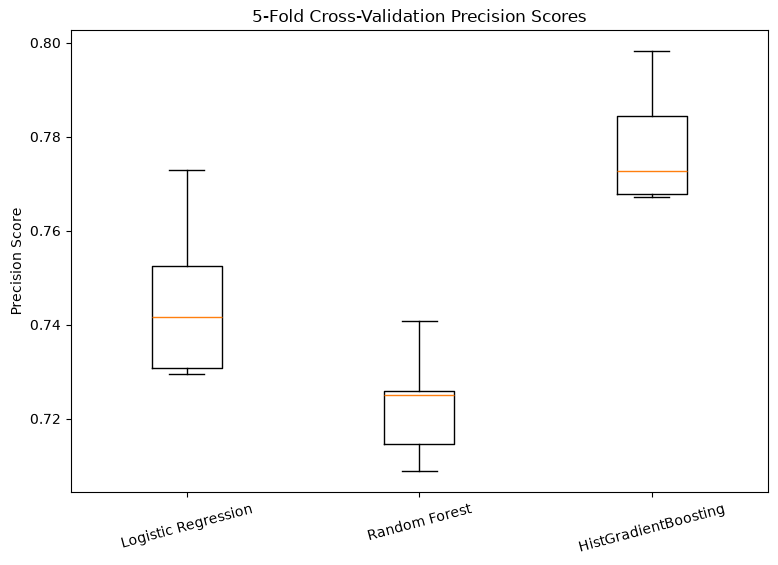

In [54]:
plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    [
        precision_scores[
            column
        ].dropna()

        for column
        in precision_scores.columns
    ],
    tick_labels=
    precision_scores.columns
)

plt.ylabel(
    "Precision Score"
)

plt.title(
    "5-Fold Cross-Validation Precision Scores"
)

plt.xticks(
    rotation=15
)

plt.show()

In [55]:
roc_auc_scores = pd.DataFrame({
    model_name:
    scores["test_roc_auc"]

    for model_name, scores
    in cv_results.items()
})

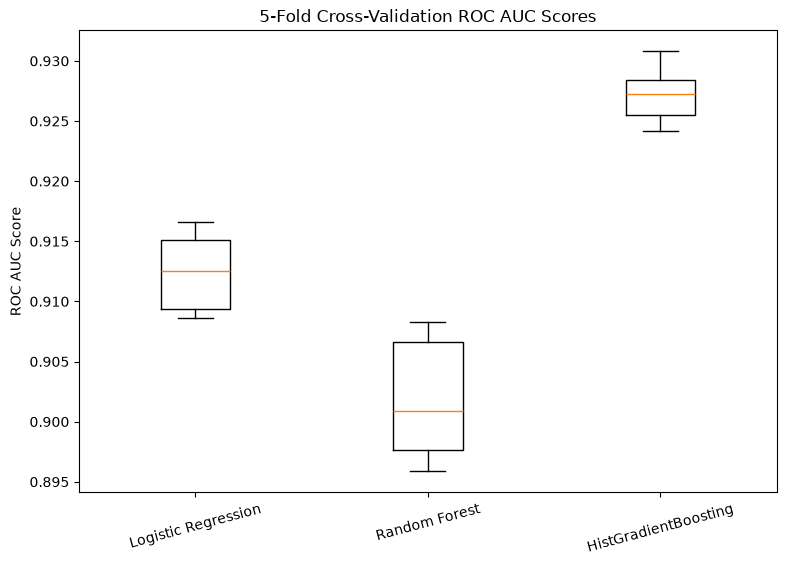

In [56]:
plt.figure(
    figsize=(9, 6)
)

plt.boxplot(
    [
        roc_auc_scores[
            column
        ].dropna()

        for column
        in roc_auc_scores.columns
    ],
    tick_labels=
    roc_auc_scores.columns
)

plt.ylabel(
    "ROC AUC Score"
)

plt.title(
    "5-Fold Cross-Validation ROC AUC Scores"
)

plt.xticks(
    rotation=15
)

plt.show()

The precision boxplot shows that HistGradientBoosting achieved the highest overall distribution of precision scores across the five folds. Its relatively low standard deviation of 0.0118 also indicates stable performance across different validation subsets.

Logistic Regression showed slightly greater variation, with a precision standard deviation of 0.0161, while Random Forest was relatively stable but had a lower average precision. Overall, the cross-validation distributions support HistGradientBoosting as the strongest and most reliable model based on the selected primary metric.

The ROC AUC results show a similar pattern. HistGradientBoosting achieved the highest average ROC AUC and the lowest variation across folds, indicating strong and consistent ability to distinguish between individuals earning above and below $50K.

# Task 4

In [57]:
cv_summary.sort_values(
    by="Precision Mean",
    ascending=False
)

,Model,Precision Mean,Precision Std,ROC AUC Mean,ROC AUC Std,F1 Mean,F1 Std
2,HistGradientBoosting,0.778084,0.011760,0.927218,0.002310,0.708016,0.008927
0,Logistic Regression,0.745465,0.016081,0.912463,0.003111,0.673138,0.010056
1,Random Forest,0.723047,0.010990,0.901864,0.004868,0.666527,0.010920


In [58]:
top_model_1 = "HistGradientBoosting"
top_model_2 = "Logistic Regression"

### Paired t-Test

In [59]:
from scipy.stats import ttest_rel

top_model_1_scores = (
    cv_results[
        top_model_1
    ][
        "test_precision"
    ]
)

top_model_2_scores = (
    cv_results[
        top_model_2
    ][
        "test_precision"
    ]
)

t_statistic, p_value = ttest_rel(
    top_model_1_scores,
    top_model_2_scores
)

print(
    "Model 1:",
    top_model_1
)

print(
    "Model 2:",
    top_model_2
)

print(
    "T-statistic:",
    t_statistic
)

print(
    "P-value:",
    p_value
)

Model 1: HistGradientBoosting
Model 2: Logistic Regression
T-statistic: 14.198849044286208
P-value: 0.00014286057603877188


The two best models based on cross-validated precision were HistGradientBoosting and Logistic Regression. A paired t-test was performed using their precision scores across the same five cross-validation folds.

The test produced a t-statistic of 14.1988 and a p-value of 0.000143. Since the p-value is substantially below the conventional significance threshold of 0.05, the difference in precision between the two models is statistically significant.

From a practical perspective, HistGradientBoosting achieved a mean precision of 0.7781, compared with 0.7455 for Logistic Regression, representing an improvement of approximately 3.26 percentage points. Therefore, the improvement is not only statistically significant but also meaningful for the selected business objective of reducing wasted outreach to individuals who are unlikely to belong to the high-income class.

### Feature Importance

In [61]:
rf_cv_pipeline.fit(
    X_train_dev,
    y_train_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note

In [62]:
rf_preprocessor = (
    rf_cv_pipeline
    .named_steps[
        "preprocessor"
    ]
)

In [63]:
rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [64]:
rf_model_fitted = (
    rf_cv_pipeline
    .named_steps[
        "model"
    ]
)

In [65]:
feature_importances = pd.DataFrame({
    "Feature":
        rf_feature_names,

    "Importance":
        rf_model_fitted
        .feature_importances_
})

In [66]:
feature_importances = (
    feature_importances
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importances.head(20)

,Feature,Importance
1,num__fnlwgt,0.147217
0,num__age,0.109868
9,num__education_hours_interaction,0.072298
36,cat__marital-status_Married-civ-spouse,0.065315
3,num__capital-gain,0.051928
7,num__log_capital_gain,0.043220
2,num__education-num,0.039999
55,cat__relationship_Husband,0.039284
5,num__hours-per-week,0.039137
4,num__capital-loss,0.027914


In [67]:
engineered_keywords = [
    "age_bucket",
    "hours_bucket",
    "capital_gain_flag",
    "log_capital_gain",
    "higher_education",
    "education_hours_interaction"
]

engineered_importance = feature_importances[
    feature_importances[
        "Feature"
    ].str.contains(
        "|".join(
            engineered_keywords
        ),
        regex=True
    )
].sort_values(
    by="Importance",
    ascending=False
)

engineered_importance

,Feature,Importance
9,num__education_hours_interaction,0.072298
7,num__log_capital_gain,0.043220
8,num__higher_education,0.023848
6,num__capital_gain_flag,0.012182
113,cat__age_bucket_Young,0.011475
110,cat__age_bucket_Mid_Career,0.010380
114,cat__hours_bucket_Long_Hours,0.008630
112,cat__age_bucket_Senior,0.007547
109,cat__age_bucket_Early_Career,0.006912
116,cat__hours_bucket_Standard,0.005101


Most Important Engineered Features

1. education_hours_interaction — Importance: 0.072298
This was the strongest engineered feature in the Random Forest model. It suggests that the combination of educational attainment and working hours provides stronger predictive information than treating these variables entirely independently.

2. log_capital_gain — Importance: 0.043220
The logarithmic transformation helped represent the highly skewed capital-gain distribution more effectively by reducing the influence of extreme values.

3. higher_education — Importance: 0.023848
This feature explicitly captures whether an individual has a higher level of education, which is reasonably associated with a greater probability of earning above $50K.

4. capital_gain_flag — Importance: 0.012182
Although less important than the continuous log transformation, simply identifying whether an individual has any capital gain still provided useful predictive information.

### Logistic Regression Coefficients for Engineered Features

In [68]:
logistic_cv_pipeline.fit(
    X_train_dev,
    y_train_dev
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note

In [69]:
log_preprocessor = (
    logistic_cv_pipeline
    .named_steps[
        "preprocessor"
    ]
)

log_feature_names = (
    log_preprocessor
    .get_feature_names_out()
)

log_model_fitted = (
    logistic_cv_pipeline
    .named_steps[
        "model"
    ]
)

log_coef_df = pd.DataFrame({
    "Feature":
        log_feature_names,

    "Coefficient":
        log_model_fitted
        .coef_[0]
})

In [70]:
engineered_coefficients = (
    log_coef_df[
        log_coef_df[
            "Feature"
        ].str.contains(
            "|".join(
                engineered_keywords
            ),
            regex=True
        )
    ]
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

engineered_coefficients

,Feature,Coefficient
7,num__log_capital_gain,6.239313
110,cat__age_bucket_Mid_Career,0.400778
112,cat__age_bucket_Senior,0.195165
114,cat__hours_bucket_Long_Hours,0.117620
8,num__higher_education,0.101691
109,cat__age_bucket_Early_Career,-0.063041
116,cat__hours_bucket_Standard,-0.190264
9,num__education_hours_interaction,-0.269632
117,cat__hours_bucket_Very_Long_Hours,-0.455346
115,cat__hours_bucket_Part_Time,-0.712202


1. Strongest positive effect: log_capital_gain (6.239) has the largest positive coefficient, indicating that higher transformed capital gain is strongly associated with higher-income classification.
2. Other positive features: Mid_Career (0.401), Senior (0.195), higher_education (0.102), and Long_Hours (0.118) are positively associated with higher income.
3. Negative features: Young (−1.042), Older (−0.731), and Part_Time (−0.712) are associated with a lower probability of the positive class.
4. Interaction feature: education_hours_interaction (−0.270) is negative in Logistic Regression but highly important in Random Forest. This suggests the relationship may be nonlinear or more complex, which Random Forest can capture better than a linear model.
5. Important caution: capital_gain_flag (−5.850) should not be interpreted on its own because it is closely related to capital_gain and log_capital_gain. These correlated/redundant features can cause multicollinearity, making Logistic Regression coefficients unstable or even reversing their apparent direction.

# Task 5

In [71]:
from sklearn.feature_selection import (
    SelectKBest,
    mutual_info_classif
)

In [72]:
feature_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=50
)

In [73]:
logistic_fs_pipeline = Pipeline(
    steps=[
        (
            "feature_engineering",
            AdultFeatureEngineer()
        ),
        (
            "preprocessor",
            preprocessor_engineered
        ),
        (
            "feature_selection",
            SelectKBest(
                score_func=mutual_info_classif,
                k=50
            )
        ),
        (
            "model",
            LogisticRegression(
                random_state=RANDOM_STATE,
                solver="liblinear",
                max_iter=2000
            )
        )
    ]
)

In [75]:
import time

# Without selection:
start_time = time.time()

logistic_no_fs_scores = cross_validate(
    logistic_cv_pipeline,
    X_train_dev,
    y_train_dev,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

no_fs_time = (
    time.time()
    -
    start_time
)

In [76]:
# Without selection:

start_time = time.time()

logistic_fs_scores = cross_validate(
    logistic_fs_pipeline,
    X_train_dev,
    y_train_dev,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

fs_time = (
    time.time()
    -
    start_time
)

In [77]:
feature_selection_comparison = pd.DataFrame([
    {
        "Approach":
            "Without Feature Selection",

        "Precision Mean":
            logistic_no_fs_scores[
                "test_precision"
            ].mean(),

        "ROC AUC Mean":
            logistic_no_fs_scores[
                "test_roc_auc"
            ].mean(),

        "F1 Mean":
            logistic_no_fs_scores[
                "test_f1"
            ].mean(),

        "Training Time (seconds)":
            no_fs_time
    },

    {
        "Approach":
            "With SelectKBest (k=50)",

        "Precision Mean":
            logistic_fs_scores[
                "test_precision"
            ].mean(),

        "ROC AUC Mean":
            logistic_fs_scores[
                "test_roc_auc"
            ].mean(),

        "F1 Mean":
            logistic_fs_scores[
                "test_f1"
            ].mean(),

        "Training Time (seconds)":
            fs_time
    }
])

feature_selection_comparison

,Approach,Precision Mean,ROC AUC Mean,F1 Mean,Training Time (seconds)
0,Without Feature Selection,0.745465,0.912463,0.673138,18.259042
1,With SelectKBest (k=50),0.743393,0.910332,0.663576,29.199042


Feature selection using SelectKBest with mutual information and k=50 did not improve model performance. Without feature selection, Logistic Regression achieved a mean precision of 0.7455, ROC AUC of 0.9125, and F1 score of 0.6731.

After selecting the top 50 transformed features, performance slightly decreased to a precision of 0.7434, ROC AUC of 0.9103, and F1 score of 0.6636. In addition, the feature-selection pipeline required approximately 29.20 seconds, compared with 18.26 seconds without feature selection.

Therefore, feature selection did not provide a performance or computational advantage in this experiment. The results suggest that removing features may have discarded useful information, while the additional mutual-information calculation increased the overall computational cost.

### Features Recommended for Day 4

Based on the experimental results, feature selection with SelectKBest (k=50) will not be retained for the next stage. The original engineered feature set produced better precision, ROC AUC, F1 score, and faster execution time.

Therefore, the recommended approach for Day 4 is to retain the full preprocessing pipeline with all six engineered features:

1. age_bucket
2. hours_bucket
3. capital_gain_flag
4. log_capital_gain
5. higher_education
6. education_hours_interaction

The strongest evidence supports retaining the education-hours interaction, log-transformed capital gain, and higher-education features. The remaining engineered features will also be retained because the full feature set performed better than the reduced SelectKBest configuration.